# SwissLipids mapping coverage analysis

**Goal:** Evaluate how many Morita et al. lipids can be mapped to SwissLipids using
normalized names (exact match in the SwissLipids name index).

**Inputs:**
| File | Column used |
|---|---|
| `data/processed/swisslipids_Morita.csv` | `original_name`, `converted_name`, `strategy`, `levels` |
| `data/processed/goslin_Morita.csv` | `original_name`, `class_name` |

`swisslipids_Morita.csv` is the output of `norm_data_swisslipids.ipynb`.  
Each row was matched against the SwissLipids name index (Abbreviation + Synonyms)  
using a cascade of normalized key formats — each step is an **exact match** in the index.  
A row with `converted_name = NaN` means no format variant found a match.


In [237]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display


## Step 1 — Load mapping results and class annotations


In [238]:
# Mapping results from norm_data_swisslipids.ipynb
df_sl = pd.read_csv('../data/processed/swisslipids_Morita.csv')

# Class annotations from GOSLIN (class_name column)
df_goslin = pd.read_csv('../data/processed/goslin_Morita.csv')[['original_name', 'class_name']]

# Merge class info
df = df_sl.merge(df_goslin, on='original_name', how='left')

# Fallback: extract class from first token of original_name if class_name is missing
def extract_class(name):
    return re.match(r'^[A-Za-z]+', name).group() if re.match(r'^[A-Za-z]+', name) else 'Unknown'

df['class_name'] = df['class_name'].fillna(df['original_name'].map(extract_class))

# Define mapped / unmapped
df['mapped'] = df['converted_name'].notna()

print(f'Loaded {len(df)} lipids')
print(f'Columns: {df.columns.tolist()}')
df[['original_name', 'class_name', 'converted_name', 'strategy', 'mapped']][30:50]


Loaded 1289 lipids
Columns: ['original_name', 'normalized_name', 'converted_name', 'strategy', 'sl_ids', 'n_sl_ids', 'levels', 'class_name', 'mapped']


,original_name,class_name,converted_name,strategy,mapped
30,DG 12:0_22:6,DG,DG(12:0_22:6),paren_under,True
31,DG 14:0_14:1,DG,DG(14:0_14:1),paren_under,True
32,DG 14:0_16:0,DG,DG(14:0_16:0),paren_under,True
33,DG 14:0_16:1,DG,DG(14:0_16:1),paren_under,True
34,DG 14:0_18:0,DG,DG(14:0_18:0),paren_under,True
35,DG 14:0_18:1,DG,DG(14:0_18:1),paren_under,True
36,DG 14:0_18:2,DG,DG(14:0_18:2),paren_under,True
37,DG 14:0_18:3,DG,DG(14:0_18:3),paren_under,True
38,DG 14:0_20:1,DG,DG(14:0_20:1),paren_under,True
39,DG 14:0_20:3,DG,DG(14:0_20:3),paren_under,True


## Step 2 — Overall mapping coverage


In [239]:
n_total    = len(df)
n_mapped   = df['mapped'].sum()
n_unmapped = n_total - n_mapped

print('─' * 45)
print(f'Total lipids          : {n_total}')
print(f'Mapped                : {n_mapped}  ({n_mapped / n_total * 100:.1f}%)')
print(f'Unmapped              : {n_unmapped}  ({n_unmapped / n_total * 100:.1f}%)')
print('─' * 45)
print()

# Breakdown by matching strategy
print('Mapped — by cascade strategy:')
strat = (
    df[df['mapped']]
    .groupby('strategy')
    .size()
    .sort_values(ascending=False)
    .rename('count')
    .reset_index()
    .assign(pct=lambda d: (d['count'] / n_total * 100).round(1))
)
print(strat.to_string(index=False))


─────────────────────────────────────────────
Total lipids          : 1289
Mapped                : 1213  (94.1%)
Unmapped              : 76  (5.9%)
─────────────────────────────────────────────

Mapped — by cascade strategy:
   strategy  count  pct
paren_under   1136 88.1
       lyso     43  3.3
cer_d_slash     34  2.6


## Step 3 — Unmapped lipid list

Listed for downstream root-cause analysis.


In [240]:
df_unmapped = (
    df[~df['mapped']][['original_name', 'class_name']]
    .sort_values(['class_name', 'original_name'])
    .reset_index(drop=True)
)

print(f'Unmapped lipids ({len(df_unmapped)}):')
pd.set_option('display.max_rows', None)
display(df_unmapped)


Unmapped lipids (76):


,original_name,class_name
0,CE(16:1),CE
1,CE(18:0),CE
2,CE(18:1),CE
3,CE(18:2),CE
4,CE(18:3),CE
5,CE(20:0),CE
6,CE(20:1),CE
7,CE(20:2),CE
8,CE(20:3),CE
9,CE(20:4),CE


# Edit each lipid category
### CE
一個ずつエラーを解消していく

In [241]:
import gzip, csv, re as _re

SL_PATH = '/Users/ogawaakane/Library/Caches/pypath/swisslipids/lipids.tsv.gz'

# Build exact abbreviation set from SwissLipids
sl_abbr_set = set()
with gzip.open(SL_PATH, 'rt', encoding='latin-1') as f:
    reader = csv.DictReader(f, delimiter='\t')
    for row in reader:
        abbr = row.get('Abbreviation*', '').strip()
        if abbr:
            sl_abbr_set.add(abbr)

def fix_ce_name(norm_name):
    # CE 18:1 -> CE(18:1)  (remove space, wrap chain in parentheses)
    return _re.sub(r'^CE (\S+)$', r'CE(\1)', norm_name)

# Apply fix and check against SwissLipids
df_ce = df[df['class_name'] == 'CE'][['original_name', 'normalized_name']].copy()
df_ce['fixed_key']    = df_ce['normalized_name'].apply(fix_ce_name)
df_ce['in_sl']        = df_ce['fixed_key'].apply(lambda k: k in sl_abbr_set)
df_ce['match_status'] = df_ce['in_sl'].map(
    {True: 'Exact match', False: 'No match (geometry required)'}
)

print('CE entries after naming fix:')
print(df_ce[['original_name', 'normalized_name', 'fixed_key', 'match_status']]
      .reset_index(drop=True).to_string(index=False))

n_ce       = len(df_ce)
n_ce_match = int(df_ce['in_sl'].sum())
print(f'\nCE match rate after fix: {n_ce_match} / {n_ce}  ({n_ce_match/n_ce*100:.1f}%)')
print('Unmatched: double bond position (e.g. 9Z) required for exact lookup')

# Compute coverage table inline (does not depend on cls_stats from later cells)
_cls = (
    df.groupby('class_name')
    .agg(total=('mapped', 'count'), mapped=('mapped', 'sum'))
    .assign(unmapped=lambda d: d['total'] - d['mapped'],
            mapped_pct=lambda d: (d['mapped'] / d['total'] * 100).round(1))
    .copy()
)
_cls.loc['CE', 'mapped']     += n_ce_match
_cls.loc['CE', 'unmapped']   -= n_ce_match
_cls.loc['CE', 'mapped_pct']  = round(_cls.loc['CE', 'mapped'] / _cls.loc['CE', 'total'] * 100, 1)

print('\n' + '-' * 52)
print('Updated coverage by class (CE fix applied):')
print(_cls.sort_values('total', ascending=False).to_string())


CE entries after naming fix:
original_name normalized_name fixed_key                 match_status
     CE(16:1)         CE 16:1  CE(16:1) No match (geometry required)
     CE(18:0)         CE 18:0  CE(18:0)                  Exact match
     CE(18:1)         CE 18:1  CE(18:1) No match (geometry required)
     CE(18:2)         CE 18:2  CE(18:2) No match (geometry required)
     CE(18:3)         CE 18:3  CE(18:3) No match (geometry required)
     CE(20:0)         CE 20:0  CE(20:0)                  Exact match
     CE(20:1)         CE 20:1  CE(20:1) No match (geometry required)
     CE(20:2)         CE 20:2  CE(20:2) No match (geometry required)
     CE(20:3)         CE 20:3  CE(20:3) No match (geometry required)
     CE(20:4)         CE 20:4  CE(20:4) No match (geometry required)
     CE(20:5)         CE 20:5  CE(20:5) No match (geometry required)
     CE(22:3)         CE 22:3  CE(22:3) No match (geometry required)
     CE(22:4)         CE 22:4  CE(22:4) No match (geometry required)
     

### FA

In [242]:
def fix_fa_name(norm_name):
    # FA 18:1 -> FA(18:1)  (remove space, wrap chain in parentheses)
    return _re.sub(r'^FA (\S+)$', r'FA(\1)', norm_name)

# Apply fix and check against SwissLipids
df_fa = df[df['class_name'] == 'FA'][['original_name', 'normalized_name']].copy()
df_fa['fixed_key']    = df_fa['normalized_name'].apply(fix_fa_name)
df_fa['in_sl']        = df_fa['fixed_key'].apply(lambda k: k in sl_abbr_set)
df_fa['match_status'] = df_fa['in_sl'].map(
    {True: 'Exact match', False: 'No match (geometry required)'}
)

print('FA entries after naming fix:')
print(df_fa[['original_name', 'normalized_name', 'fixed_key', 'match_status']]
      .reset_index(drop=True).to_string(index=False))

n_fa       = len(df_fa)
n_fa_match = int(df_fa['in_sl'].sum())
print(f'\nFA match rate after fix: {n_fa_match} / {n_fa}  ({n_fa_match/n_fa*100:.1f}%)')
print('Unmatched: double bond position (e.g. 9Z) required for exact lookup')

# Update coverage table
_cls.loc['FA', 'mapped']     += n_fa_match
_cls.loc['FA', 'unmapped']   -= n_fa_match
_cls.loc['FA', 'mapped_pct']  = round(_cls.loc['FA', 'mapped'] / _cls.loc['FA', 'total'] * 100, 1)

print('\n' + '-' * 52)
print('Updated coverage by class (CE + FA fix applied):')
print(_cls.sort_values('total', ascending=False).to_string())


FA entries after naming fix:
original_name normalized_name fixed_key match_status
     FA(12:0)         FA 12:0  FA(12:0)  Exact match
     FA(14:0)         FA 14:0  FA(14:0)  Exact match
     FA(14:1)         FA 14:1  FA(14:1)  Exact match
     FA(16:0)         FA 16:0  FA(16:0)  Exact match
     FA(16:1)         FA 16:1  FA(16:1)  Exact match
     FA(18:0)         FA 18:0  FA(18:0)  Exact match
     FA(18:1)         FA 18:1  FA(18:1)  Exact match
     FA(18:2)         FA 18:2  FA(18:2)  Exact match
     FA(18:3)         FA 18:3  FA(18:3)  Exact match
     FA(18:4)         FA 18:4  FA(18:4)  Exact match
     FA(20:1)         FA 20:1  FA(20:1)  Exact match
     FA(20:2)         FA 20:2  FA(20:2)  Exact match
     FA(20:3)         FA 20:3  FA(20:3)  Exact match
     FA(20:4)         FA 20:4  FA(20:4)  Exact match
     FA(20:5)         FA 20:5  FA(20:5)  Exact match
     FA(22:1)         FA 22:1  FA(22:1)  Exact match
     FA(22:4)         FA 22:4  FA(22:4)  Exact match
     FA(22:5)    

### MG

In [243]:
def fix_mg_name(norm_name):
    # MG 18:1 -> MG(18:1)  (remove space, wrap chain in parentheses)
    return _re.sub(r'^MG (\S+)$', r'MG(\1)', norm_name)

# Apply fix and check against SwissLipids
df_mg = df[df['class_name'] == 'MG'][['original_name', 'normalized_name']].copy()
df_mg['fixed_key']    = df_mg['normalized_name'].apply(fix_mg_name)
df_mg['in_sl']        = df_mg['fixed_key'].apply(lambda k: k in sl_abbr_set)
df_mg['match_status'] = df_mg['in_sl'].map(
    {True: 'Exact match', False: 'No match (geometry required)'}
)

print('MG entries after naming fix:')
print(df_mg[['original_name', 'normalized_name', 'fixed_key', 'match_status']]
      .reset_index(drop=True).to_string(index=False))

n_mg       = len(df_mg)
n_mg_match = int(df_mg['in_sl'].sum())
print(f'\nMG match rate after fix: {n_mg_match} / {n_mg}  ({n_mg_match/n_mg*100:.1f}%)')
print('Unmatched: double bond position (e.g. 9Z) required for exact lookup')

# Update coverage table
_cls.loc['MG', 'mapped']     += n_mg_match
_cls.loc['MG', 'unmapped']   -= n_mg_match
_cls.loc['MG', 'mapped_pct']  = round(_cls.loc['MG', 'mapped'] / _cls.loc['MG', 'total'] * 100, 1)

print('\n' + '-' * 52)
print('Updated coverage by class (CE + FA + MG fix applied):')
print(_cls.sort_values('total', ascending=False).to_string())


MG entries after naming fix:
original_name normalized_name fixed_key match_status
      MG 14:0         MG 14:0  MG(14:0)  Exact match
      MG 16:0         MG 16:0  MG(16:0)  Exact match
      MG 16:1         MG 16:1  MG(16:1)  Exact match
      MG 18:0         MG 18:0  MG(18:0)  Exact match
      MG 18:1         MG 18:1  MG(18:1)  Exact match
      MG 18:2         MG 18:2  MG(18:2)  Exact match
      MG 20:0         MG 20:0  MG(20:0)  Exact match
      MG 20:1         MG 20:1  MG(20:1)  Exact match
      MG 20:2         MG 20:2  MG(20:2)  Exact match
      MG 20:3         MG 20:3  MG(20:3)  Exact match
      MG 20:5         MG 20:5  MG(20:5)  Exact match
      MG 22:0         MG 22:0  MG(22:0)  Exact match
      MG 22:6         MG 22:6  MG(22:6)  Exact match

MG match rate after fix: 13 / 13  (100.0%)
Unmatched: double bond position (e.g. 9Z) required for exact lookup

----------------------------------------------------
Updated coverage by class (CE + FA + MG fix applied):
         

### SM

In [244]:
def fix_sm_name(norm_name):
    # SM 34:1 -> SM(34:1)  (remove space, wrap chain in parentheses)
    return _re.sub(r'^SM (\S+)$', r'SM(\1)', norm_name)

# Apply fix and check against SwissLipids
df_sm = df[df['class_name'] == 'SM'][['original_name', 'normalized_name']].copy()
df_sm['fixed_key']    = df_sm['normalized_name'].apply(fix_sm_name)
df_sm['in_sl']        = df_sm['fixed_key'].apply(lambda k: k in sl_abbr_set)
df_sm['match_status'] = df_sm['in_sl'].map(
    {True: 'Exact match', False: 'No match (geometry required)'}
)

print('SM entries after naming fix:')
print(df_sm[['original_name', 'normalized_name', 'fixed_key', 'match_status']]
      .reset_index(drop=True).to_string(index=False))

n_sm       = len(df_sm)
n_sm_match = int(df_sm['in_sl'].sum())
print(f'\nSM match rate after fix: {n_sm_match} / {n_sm}  ({n_sm_match/n_sm*100:.1f}%)')
print('Unmatched: double bond position (e.g. 9Z) required for exact lookup')

# Update coverage table
_cls.loc['SM', 'mapped']     += n_sm_match
_cls.loc['SM', 'unmapped']   -= n_sm_match
_cls.loc['SM', 'mapped_pct']  = round(_cls.loc['SM', 'mapped'] / _cls.loc['SM', 'total'] * 100, 1)

print('\n' + '-' * 52)
print('Updated coverage by class (CE + FA + MG + SM fix applied):')
print(_cls.sort_values('total', ascending=False).to_string())


SM entries after naming fix:
original_name normalized_name fixed_key                 match_status
      SM 30:1         SM 30:1  SM(30:1) No match (geometry required)
      SM 32:1         SM 32:1  SM(32:1) No match (geometry required)
      SM 32:2         SM 32:2  SM(32:2) No match (geometry required)
      SM 34:1         SM 34:1  SM(34:1) No match (geometry required)
      SM 34:2         SM 34:2  SM(34:2) No match (geometry required)
      SM 36:1         SM 36:1  SM(36:1) No match (geometry required)
      SM 36:2         SM 36:2  SM(36:2) No match (geometry required)
      SM 36:3         SM 36:3  SM(36:3) No match (geometry required)
      SM 36:4         SM 36:4  SM(36:4) No match (geometry required)
      SM 36:5         SM 36:5  SM(36:5) No match (geometry required)
      SM 38:1         SM 38:1  SM(38:1) No match (geometry required)
      SM 38:2         SM 38:2  SM(38:2) No match (geometry required)
      SM 38:3         SM 38:3  SM(38:3) No match (geometry required)
     

## Final summary — mapping coverage by lipid class (all fixes applied)

In [245]:
# Rebuild from scratch to avoid cumulative update errors
# -------------------------------------------------------
# Base counts from original mapping
_summary = (
    df.groupby('class_name')
    .agg(total=('mapped', 'count'), mapped_original=('mapped', 'sum'))
    .assign(unmapped_original=lambda d: d['total'] - d['mapped_original'])
    .copy()
)

# Fixes applied per class: number of newly matched entries
fixes = {
    'CE': n_ce_match,
    'FA': n_fa_match,
    'MG': n_mg_match,
    'SM': n_sm_match,
}

_summary['fix_added'] = _summary.index.map(fixes).fillna(0).astype(int)
_summary['mapped']    = _summary['mapped_original'] + _summary['fix_added']
_summary['unmapped']  = _summary['total'] - _summary['mapped']
_summary['mapped_pct'] = (_summary['mapped'] / _summary['total'] * 100).round(1)

# Overall totals row
total_row = pd.DataFrame({
    'total':            [_summary['total'].sum()],
    'mapped_original':  [_summary['mapped_original'].sum()],
    'unmapped_original':[_summary['unmapped_original'].sum()],
    'fix_added':        [_summary['fix_added'].sum()],
    'mapped':           [_summary['mapped'].sum()],
    'unmapped':         [_summary['unmapped'].sum()],
    'mapped_pct':       [round(_summary['mapped'].sum() / _summary['total'].sum() * 100, 1)],
}, index=pd.Index(['TOTAL'], name='class_name'))

_summary_all = pd.concat([_summary.sort_values('total', ascending=False), total_row])

display(
    _summary_all[['total', 'mapped_original', 'fix_added', 'mapped', 'unmapped', 'mapped_pct']]
    .rename(columns={
        'total':            'Total',
        'mapped_original':  'Mapped (original)',
        'fix_added':        'Fix added',
        'mapped':           'Mapped (final)',
        'unmapped':         'Unmapped',
        'mapped_pct':       'Mapped %',
    })
)


,Total,Mapped (original),Fix added,Mapped (final),Unmapped,Mapped %
class_name,,,,,,
TG,638,638,0,638,0,100.0
DG,138,138,0,138,0,100.0
PE,93,93,0,93,0,100.0
PC,88,88,0,88,0,100.0
PG,61,61,0,61,0,100.0
PI,56,56,0,56,0,100.0
PS,38,38,0,38,0,100.0
SM,26,0,0,0,26,0.0
Cer,24,24,0,24,0,100.0


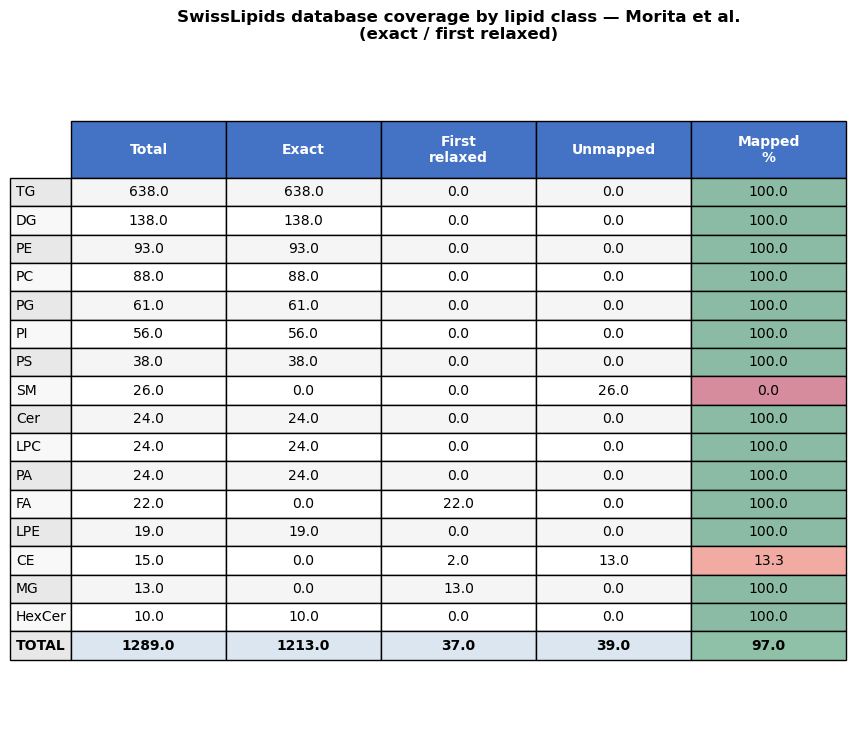

Saved -> ../results/plots/swisslipids_coverage_by_class.png


In [246]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --- prepare display table ---
tbl = (
    _summary_all[["total", "mapped_original", "fix_added", "unmapped", "mapped_pct"]]
    .rename(columns={
        "total":            "Total",
        "mapped_original":  "Exact",
        "fix_added":        "First\nrelaxed",
        "unmapped":         "Unmapped",
        "mapped_pct":       "Mapped\n%",
    })
)

col_labels  = tbl.columns.tolist()
row_labels  = tbl.index.tolist()
cell_values = tbl.values.tolist()

# --- color: Mapped % column uses RdYlGn colormap ---
pct_col_idx = col_labels.index("Mapped\n%")
cmap = plt.cm.RdYlGn

def pct_color(val):
    try:
        rgba = cmap(float(val) / 100)
        # blend with white (70%) to get pastel tone
        pastel = tuple(c * 0.45 + 1.0 * 0.55 for c in rgba[:3])
        return mcolors.to_hex(pastel)
    except Exception:
        return "#ffffff"

cell_colors = []
for i, row in enumerate(cell_values):
    base = "#f5f5f5" if i % 2 == 0 else "#ffffff"
    row_c = [base] * len(col_labels)
    row_c[pct_col_idx] = pct_color(row[pct_col_idx])
    if row_labels[i] == "TOTAL":
        row_c = ["#dce6f0"] * len(col_labels)
        row_c[pct_col_idx] = pct_color(row[pct_col_idx])
    cell_colors.append(row_c)

# --- draw ---
n_rows = len(row_labels)
fig, ax = plt.subplots(figsize=(10, max(3.5, 0.45 * n_rows + 1.4)))
ax.axis("off")

the_table = ax.table(
    cellText    = cell_values,
    rowLabels   = row_labels,
    colLabels   = col_labels,
    cellColours = cell_colors,
    rowColours  = ["#e8e8e8" if i % 2 == 0 else "#f8f8f8" for i in range(n_rows)],
    colColours  = ["#4472c4"] * len(col_labels),
    loc         = "center",
    cellLoc     = "center",
)
the_table.auto_set_font_size(False)
the_table.set_fontsize(10)
the_table.scale(1, 1.7)

# header row: increase height to fit 2-line labels
for j in range(len(col_labels)):
    the_table[0, j].set_height(the_table[0, j].get_height() * 2.0)
    the_table[0, j].set_text_props(color="white", fontweight="bold")

# TOTAL row: bold
for j in range(-1, len(col_labels)):
    the_table[n_rows, j].set_text_props(fontweight="bold")

ax.set_title(
    "SwissLipids database coverage by lipid class — Morita et al.\n(exact / first relaxed)",
    fontsize=12, fontweight="bold", pad = 0,
)

out_path = "../results/plots/swisslipids_coverage_by_class.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {out_path}")

# Travel the tree and get "relaxed match" 

In [247]:
# All lipids still unmatched after all fixes (CE / FA / MG / SM)
df_still_unmatched = pd.concat([
    df_ce[~df_ce['in_sl']][['original_name', 'fixed_key']].assign(class_name='CE'),
    df_fa[~df_fa['in_sl']][['original_name', 'fixed_key']].assign(class_name='FA'),
    df_mg[~df_mg['in_sl']][['original_name', 'fixed_key']].assign(class_name='MG'),
    df_sm[~df_sm['in_sl']][['original_name', 'fixed_key']].assign(class_name='SM'),
]).reset_index(drop=True)

print(f'Still unmatched after all fixes: {len(df_still_unmatched)} lipids')
display(df_still_unmatched[['class_name', 'original_name', 'fixed_key']])


Still unmatched after all fixes: 39 lipids


,class_name,original_name,fixed_key
0,CE,CE(16:1),CE(16:1)
1,CE,CE(18:1),CE(18:1)
2,CE,CE(18:2),CE(18:2)
3,CE,CE(18:3),CE(18:3)
4,CE,CE(20:1),CE(20:1)
5,CE,CE(20:2),CE(20:2)
6,CE,CE(20:3),CE(20:3)
7,CE,CE(20:4),CE(20:4)
8,CE,CE(20:5),CE(20:5)
9,CE,CE(22:3),CE(22:3)


In [248]:
# Browse SwissLipids abbreviations for CE and SM
def show_sl_entries(cls, abbr_set, head=20, tail=20):
    hits = sorted(a for a in abbr_set if a.startswith(cls + '(') or a.startswith(cls + ' '))
    n = len(hits)
    print(f'=== {cls} in SwissLipids ===')
    print(f'  Total entries : {n}')
    if n == 0:
        print('  (no entries found)')
    elif n <= head + tail:
        print(f'  Showing all {n} entries:')
        for h in hits:
            print(f'    {h}')
    else:
        print(f'  Showing first {head} entries:')
        for h in hits[:head]:
            print(f'    {h}')
        print(f'  ... ({n - head - tail} entries omitted) ...')
        print(f'  Last {tail} entries:')
        for h in hits[-tail:]:
            print(f'    {h}')
    print()

show_sl_entries('CE', sl_abbr_set, head=15, tail=15)
show_sl_entries('SM', sl_abbr_set, head=30, tail=30)


=== CE in SwissLipids ===
  Total entries : 85
  Showing first 15 entries:
    CE(10:0)
    CE(12:0)
    CE(13:0)
    CE(14:0)
    CE(14:1(9Z))
    CE(15:0)
    CE(16:0)
    CE(16:1(6Z))
    CE(16:1(9Z))
    CE(16:2(9Z,12Z))
    CE(17:0)
    CE(18:0)
    CE(18:1(11E))
    CE(18:1(11Z))
    CE(18:1(6Z))
  ... (55 entries omitted) ...
  Last 15 entries:
    CE(34:6(16Z,19Z,22Z,25Z,28Z,31Z))
    CE(36:4(21Z,24Z,27Z,30Z))
    CE(36:5(18Z,21Z,24Z,27Z,30Z))
    CE(36:5(21Z,24Z,27Z,30Z,33Z))
    CE(36:6(18Z,21Z,24Z,27Z,30Z,33Z))
    CE(38:4(23Z,26Z,29Z,32Z))
    CE(38:5(20Z,23Z,26Z,29Z,32Z))
    CE(38:5(23Z,26Z,29Z,32Z,35Z))
    CE(3:0)
    CE(4:0)
    CE(6:0)
    CE(8:0)
    CE(iso13:0)
    CE(iso15:0)
    CE(iso17:0)

=== SM in SwissLipids ===
  Total entries : 2364
  Showing first 30 entries:
    SM(d14:0)
    SM(d14:0/10:0)
    SM(d14:0/12:0)
    SM(d14:0/13:0)
    SM(d14:0/14:0)
    SM(d14:0/14:1(9Z))
    SM(d14:0/14:1)
    SM(d14:0/15:0)
    SM(d14:0/16:0)
    SM(d14:0/16:1(6Z))
    SM(

# Relaxed match -CE- 

In [249]:
# Relaxed match:
# Condition: lipid class matches AND the chain string inside ()
#            from Morita appears as a prefix inside () of a SwissLipids entry.
# e.g. CE(18:1) -> class='CE', chain='18:1'
#      matches CE(18:1(9Z)), CE(18:1(11Z)), ... in SwissLipids

def relaxed_candidates(fixed_key, abbr_set):
    """Return all SL entries where class matches and chain is a prefix match."""
    m = _re.match(r'^([A-Za-z]+)\((.+)\)$', fixed_key)
    if not m:
        return []
    cls, chain = m.group(1), m.group(2)
    prefix = f'{cls}({chain}'
    return sorted(a for a in abbr_set if a.startswith(prefix))

# Apply to all still-unmatched entries
df_still_unmatched['relaxed_candidates'] = df_still_unmatched['fixed_key'].apply(
    lambda k: relaxed_candidates(k, sl_abbr_set)
)
df_still_unmatched['relaxed_match'] = df_still_unmatched['relaxed_candidates'].apply(
    lambda c: len(c) > 0
)

# --- Show results ---
print('=== Relaxed match results ===')
print(f'Unmatched total : {len(df_still_unmatched)}')
print(f'Relaxed matched : {df_still_unmatched["relaxed_match"].sum()}')
print(f'Still no match  : {(~df_still_unmatched["relaxed_match"]).sum()}')
print()

print('--- Relaxed matched entries ---')
for _, row in df_still_unmatched[df_still_unmatched['relaxed_match']].iterrows():
    print(f"  {row['fixed_key']:20s} -> {row['relaxed_candidates']}")
print()

print('--- Still unmatched ---')
for _, row in df_still_unmatched[~df_still_unmatched['relaxed_match']].iterrows():
    print(f"  {row['fixed_key']}")
print()

# --- Update summary table ---
relaxed_by_cls = (
    df_still_unmatched[df_still_unmatched['relaxed_match']]
    .groupby('class_name')
    .size()
)

_summary['relaxed_added'] = _summary.index.map(relaxed_by_cls).fillna(0).astype(int)
_summary['mapped_final']  = _summary['mapped'] + _summary['relaxed_added']
_summary['unmapped_final']= _summary['total'] - _summary['mapped_final']
_summary['mapped_pct_final'] = (_summary['mapped_final'] / _summary['total'] * 100).round(1)

total_row2 = pd.DataFrame({
    'total':             [_summary['total'].sum()],
    'mapped_original':   [_summary['mapped_original'].sum()],
    'fix_added':         [_summary['fix_added'].sum()],
    'mapped':            [_summary['mapped'].sum()],
    'relaxed_added':     [_summary['relaxed_added'].sum()],
    'mapped_final':      [_summary['mapped_final'].sum()],
    'unmapped_final':    [_summary['unmapped_final'].sum()],
    'mapped_pct_final':  [round(_summary['mapped_final'].sum() / _summary['total'].sum() * 100, 1)],
}, index=pd.Index(['TOTAL'], name='class_name'))

_summary_final = pd.concat([_summary.sort_values('total', ascending=False), total_row2])

print('=== Updated coverage (including relaxed match) ===')
display(
    _summary_final[['total', 'mapped_original', 'fix_added', 'relaxed_added',
                     'mapped_final', 'unmapped_final', 'mapped_pct_final']]
    .rename(columns={
        'total':            'Total',
        'mapped_original':  'Mapped (original)',
        'fix_added':        'Fix added',
        'relaxed_added':    'Relaxed added',
        'mapped_final':     'Mapped (final)',
        'unmapped_final':   'Unmapped',
        'mapped_pct_final': 'Mapped %',
    })
)


=== Relaxed match results ===
Unmatched total : 39
Relaxed matched : 13
Still no match  : 26

--- Relaxed matched entries ---
  CE(16:1)             -> ['CE(16:1(6Z))', 'CE(16:1(9Z))']
  CE(18:1)             -> ['CE(18:1(11E))', 'CE(18:1(11Z))', 'CE(18:1(6Z))', 'CE(18:1(9Z))']
  CE(18:2)             -> ['CE(18:2(9Z,11E))', 'CE(18:2(9Z,12Z))']
  CE(18:3)             -> ['CE(18:3(6Z,9Z,12Z))', 'CE(18:3(9Z,12Z,15Z))']
  CE(20:1)             -> ['CE(20:1(11Z))']
  CE(20:2)             -> ['CE(20:2(11Z,14Z))']
  CE(20:3)             -> ['CE(20:3(11Z,14Z,17Z))', 'CE(20:3(8Z,11Z,14Z))']
  CE(20:4)             -> ['CE(20:4(5Z,8Z,11Z,14Z))', 'CE(20:4(8Z,11Z,14Z,17Z))']
  CE(20:5)             -> ['CE(20:5(5Z,8Z,11Z,14Z,17Z))']
  CE(22:3)             -> ['CE(22:3(10Z,13Z,16Z))']
  CE(22:4)             -> ['CE(22:4(7Z,10Z,13Z,16Z))']
  CE(22:5)             -> ['CE(22:5(4Z,7Z,10Z,13Z,16Z))', 'CE(22:5(7Z,10Z,13Z,16Z,19Z))']
  CE(22:6)             -> ['CE(22:6(4Z,7Z,10Z,13Z,16Z,19Z))']

--- Still unm

,Total,Mapped (original),Fix added,Relaxed added,Mapped (final),Unmapped,Mapped %
class_name,,,,,,,
TG,638,638,0,0,638,0,100.0
DG,138,138,0,0,138,0,100.0
PE,93,93,0,0,93,0,100.0
PC,88,88,0,0,88,0,100.0
PG,61,61,0,0,61,0,100.0
PI,56,56,0,0,56,0,100.0
PS,38,38,0,0,38,0,100.0
SM,26,0,0,0,0,26,0.0
Cer,24,24,0,0,24,0,100.0


# Realxed match -SM- 

In [250]:
# Relaxed match for SM with d/t prefix:
# Morita SM(34:1) -> chain='34:1'
# matches SwissLipids SM(d34:1), SM(t34:1), etc.

def relaxed_candidates_dt(fixed_key, abbr_set):
    """Like relaxed_candidates, but also try d/t prefix before the chain."""
    m = _re.match(r'^([A-Za-z]+)\((.+)\)$', fixed_key)
    if not m:
        return []
    cls, chain = m.group(1), m.group(2)
    candidates = set()
    for prefix in [f'{cls}({chain}',
                   f'{cls}(d{chain}',
                   f'{cls}(t{chain}']:
        candidates.update(a for a in abbr_set if a.startswith(prefix))
    return sorted(candidates)

# Apply only to SM entries still unmatched after previous relaxed match
df_sm_still = df_still_unmatched[
    (df_still_unmatched['class_name'] == 'SM') &
    (~df_still_unmatched['relaxed_match'])
].copy()

df_sm_still['relaxed_candidates_dt'] = df_sm_still['fixed_key'].apply(
    lambda k: relaxed_candidates_dt(k, sl_abbr_set)
)
df_sm_still['relaxed_match_dt'] = df_sm_still['relaxed_candidates_dt'].apply(
    lambda c: len(c) > 0
)

# --- Show results ---
print('=== SM relaxed match (d/t prefix) ===')
print(f'SM still unmatched before this step : {len(df_sm_still)}')
print(f'Newly matched (d/t prefix)           : {df_sm_still["relaxed_match_dt"].sum()}')
print(f'Still no match                       : {(~df_sm_still["relaxed_match_dt"]).sum()}')
print()

print('--- Newly matched entries ---')
for _, row in df_sm_still[df_sm_still['relaxed_match_dt']].iterrows():
    print(f"  {row['fixed_key']:20s} -> {row['relaxed_candidates_dt']}")
print()

print('--- Still unmatched ---')
for _, row in df_sm_still[~df_sm_still['relaxed_match_dt']].iterrows():
    print(f"  {row['fixed_key']}")
print()

# --- Update summary table ---
n_sm_relaxed_dt = int(df_sm_still['relaxed_match_dt'].sum())

_summary.loc['SM', 'relaxed_added']      += n_sm_relaxed_dt
_summary.loc['SM', 'mapped_final']       += n_sm_relaxed_dt
_summary.loc['SM', 'unmapped_final']     -= n_sm_relaxed_dt
_summary.loc['SM', 'mapped_pct_final']    = round(
    _summary.loc['SM', 'mapped_final'] / _summary.loc['SM', 'total'] * 100, 1
)

# Rebuild TOTAL row
total_row3 = pd.DataFrame({
    'total':             [_summary['total'].sum()],
    'mapped_original':   [_summary['mapped_original'].sum()],
    'fix_added':         [_summary['fix_added'].sum()],
    'mapped':            [_summary['mapped'].sum()],
    'relaxed_added':     [_summary['relaxed_added'].sum()],
    'mapped_final':      [_summary['mapped_final'].sum()],
    'unmapped_final':    [_summary['unmapped_final'].sum()],
    'mapped_pct_final':  [round(_summary['mapped_final'].sum() / _summary['total'].sum() * 100, 1)],
}, index=pd.Index(['TOTAL'], name='class_name'))

_summary_final2 = pd.concat([_summary.sort_values('total', ascending=False), total_row3])

print('=== Updated coverage (exact + fix + relaxed + SM d/t) ===')
display(
    _summary_final2[['total', 'mapped_original', 'fix_added', 'relaxed_added',
                      'mapped_final', 'unmapped_final', 'mapped_pct_final']]
    .rename(columns={
        'total':            'Total',
        'mapped_original':  'Mapped (original)',
        'fix_added':        'Fix added',
        'relaxed_added':    'Relaxed added',
        'mapped_final':     'Mapped (final)',
        'unmapped_final':   'Unmapped',
        'mapped_pct_final': 'Mapped %',
    })
)


=== SM relaxed match (d/t prefix) ===
SM still unmatched before this step : 26
Newly matched (d/t prefix)           : 26
Still no match                       : 0

--- Newly matched entries ---
  SM(30:1)             -> ['SM(d30:1)', 'SM(t30:1)']
  SM(32:1)             -> ['SM(d32:1)', 'SM(t32:1)']
  SM(32:2)             -> ['SM(d32:2)', 'SM(t32:2)']
  SM(34:1)             -> ['SM(d34:1)', 'SM(t34:1)']
  SM(34:2)             -> ['SM(d34:2)', 'SM(t34:2)']
  SM(36:1)             -> ['SM(d36:1)', 'SM(t36:1)']
  SM(36:2)             -> ['SM(d36:2)', 'SM(t36:2)']
  SM(36:3)             -> ['SM(d36:3)', 'SM(t36:3)']
  SM(36:4)             -> ['SM(d36:4)', 'SM(t36:4)']
  SM(36:5)             -> ['SM(d36:5)', 'SM(t36:5)']
  SM(38:1)             -> ['SM(d38:1)', 'SM(t38:1)']
  SM(38:2)             -> ['SM(d38:2)', 'SM(t38:2)']
  SM(38:3)             -> ['SM(d38:3)', 'SM(t38:3)']
  SM(38:4)             -> ['SM(d38:4)', 'SM(t38:4)']
  SM(38:5)             -> ['SM(d38:5)', 'SM(t38:5)']
  SM(38:6)  

,Total,Mapped (original),Fix added,Relaxed added,Mapped (final),Unmapped,Mapped %
class_name,,,,,,,
TG,638,638,0,0,638,0,100.0
DG,138,138,0,0,138,0,100.0
PE,93,93,0,0,93,0,100.0
PC,88,88,0,0,88,0,100.0
PG,61,61,0,0,61,0,100.0
PI,56,56,0,0,56,0,100.0
PS,38,38,0,0,38,0,100.0
SM,26,0,0,26,26,0,100.0
Cer,24,24,0,0,24,0,100.0


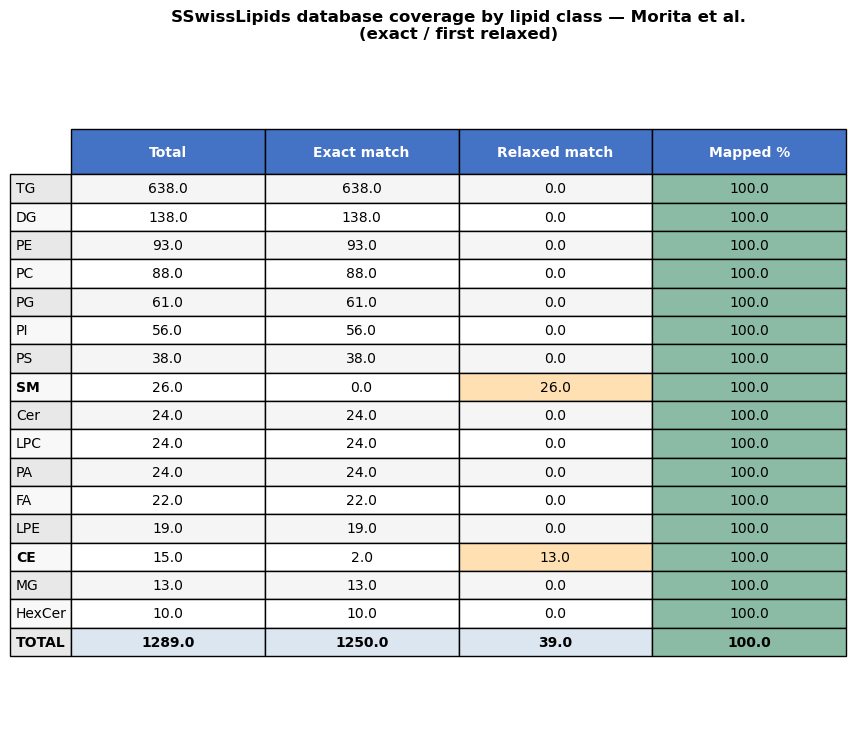

Saved -> ../results/plots/swisslipids_final_coverage.png


In [253]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --- Build display table ---
# exact match = mapped_original + fix_added
# relaxed match = relaxed_added (CE relaxed + SM d/t)
tbl_final = _summary[['total', 'mapped_original', 'fix_added',
                        'relaxed_added', 'mapped_pct_final']].copy()
tbl_final['exact_match'] = tbl_final['mapped_original'] + tbl_final['fix_added']
tbl_final = tbl_final[['total', 'exact_match', 'relaxed_added', 'mapped_pct_final']]
tbl_final = tbl_final.sort_values('total', ascending=False)

# TOTAL row
total_vals = {
    'total':            tbl_final['total'].sum(),
    'exact_match':      tbl_final['exact_match'].sum(),
    'relaxed_added':    tbl_final['relaxed_added'].sum(),
    'mapped_pct_final': round(
        (tbl_final['exact_match'].sum() + tbl_final['relaxed_added'].sum())
        / tbl_final['total'].sum() * 100, 1),
}
total_row = pd.DataFrame(total_vals, index=pd.Index(['TOTAL'], name='class_name'))
tbl_final = pd.concat([tbl_final, total_row])

col_labels  = ['Total', 'Exact match', 'Relaxed match', 'Mapped %']
row_labels  = tbl_final.index.tolist()
cell_values = tbl_final.values.tolist()

# Rows that used relaxed match
RELAXED_CLASSES = {'CE', 'SM'}
relaxed_col_idx = 2   # 'Relaxed match'
pct_col_idx     = 3   # 'Mapped %'

# --- Colors ---
cmap = plt.cm.RdYlGn

def pct_color(val):
    try:
        rgba = cmap(float(val) / 100)
        pastel = tuple(c * 0.45 + 0.55 for c in rgba[:3])
        return mcolors.to_hex(pastel)
    except Exception:
        return '#ffffff'

RELAXED_HIGHLIGHT = '#ffe0b2'  # pastel orange — Relaxed match cell

cell_colors = []
for i, row in enumerate(cell_values):
    cls = row_labels[i]
    base = '#f5f5f5' if i % 2 == 0 else '#ffffff'
    row_c = [base] * len(col_labels)
    row_c[pct_col_idx] = pct_color(row[pct_col_idx])
    if cls == 'TOTAL':
        row_c = ['#dce6f0'] * len(col_labels)
        row_c[pct_col_idx] = pct_color(row[pct_col_idx])
    elif cls in RELAXED_CLASSES:
        row_c[relaxed_col_idx] = RELAXED_HIGHLIGHT
    cell_colors.append(row_c)

# --- Draw ---
n_rows = len(row_labels)
fig, ax = plt.subplots(figsize=(10, max(3.5, 0.45 * n_rows + 1.4)))
ax.axis('off')

the_table = ax.table(
    cellText    = cell_values,
    rowLabels   = row_labels,
    colLabels   = col_labels,
    cellColours = cell_colors,
    rowColours  = ['#e8e8e8' if i % 2 == 0 else '#f8f8f8' for i in range(n_rows)],
    colColours  = ['#4472c4'] * len(col_labels),
    loc         = 'center',
    cellLoc     = 'center',
)
the_table.auto_set_font_size(False)
the_table.set_fontsize(10)
the_table.scale(1, 1.7)

# Header: white bold, taller
for j in range(len(col_labels)):
    the_table[0, j].set_height(the_table[0, j].get_height() * 1.6)
    the_table[0, j].set_text_props(color='white', fontweight='bold')

# CE / SM row labels: bold to match the highlight
for i, cls in enumerate(row_labels):
    if cls in RELAXED_CLASSES:
        the_table[i + 1, -1].set_text_props(fontweight='bold')

# TOTAL row: bold
for j in range(-1, len(col_labels)):
    the_table[n_rows, j].set_text_props(fontweight='bold')

ax.set_title(
    'SSwissLipids database coverage by lipid class — Morita et al.\n'
    '(exact / first relaxed)',
    fontsize=12, fontweight='bold', pad=4,
)


out_path = '../results/plots/swisslipids_final_coverage.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {out_path}')
